<a href="https://colab.research.google.com/github/dcthyun0308/ESAA/blob/main/ESAA_OB_week11_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#8.3 하이퍼파라미터를 이용한 성능 최적화

##8.3.1 하이퍼파라미터를 이용한 성능 최적화

### 정규화
- 데이터 범위를 사용자가 원하는 범위로 제한하는 것. 정규화는 각 특성 범위를 조정한다는 의미로 특성 스케일링이라고도 함.

### 규제화
- 모델 복잡도를 줄이기 위해 제약을 두는 방법. 이때 제약은 데이터가 네트워크에 들어가기 전에 필터를 적용한 것이라고 생각하면 됨.

### 표준화
- 기존 데이터를 평균은 0, 표준편차는 1인 형태의 데이터로 만드는 방법.

### 배치 정규화
- 기울기 소멸이나 기울기 폭발같은 문제를 해결하기 위한 방법. 일반적으로 기울기 소멸이나 폭발 문제를 해결하기 위해 손실 함수로 렐루를 사용하거나 초깃값 튜닝, 학습률 등을 조정함.

- 기울기 소멸 : 오차 정보를 역전파시키는 과정에서 기울기가 급격히 0에 가까워져 학습이 되지 않는 현상임.

- 기울기 폭발 : 학습 과정에서 기울기가 급격히 커지는 현상임.

## 8.3.2 드롭아웃을 이용한 성능 최적화
- 과적합은 훈련 데이터셋을 과하게 학습 하는 것. 일반적으로 훈련 데이터셋은 실제 데이터셋이 부분 집합이므로 훈련 데이터셋에 대해서는 오류가 감소하지만, 테스트 데이터셋에 대해서는 오류가 증가함.

- 드롭아웃은 훈련할 때 일정 비율의 뉴런만 사용하고, 나머지 뉴런에 해당하는 가중치는 업데이트하지 않는 방법임. 물론 매 단계마다 사용하지 않는 뉴런을 바꾸어 가며 훈련시킴. 즉, 드롭아웃은 노드를 임의로 끄면서 학습하는 방법으로, 은닉층에 배치된 노드 중 일부로 임의로 끄면서 학습함. 꺼진 노드는 신호를 전달하지 않으므로 지나친 학습을 방지하는 효과 생김.

배치 정규화와 드롭아웃에 대한 파이토치 예제를 알아보자. 여기에서 사용되는 데이터셋은 파이토치 torchvision.datasets에서 제공하는 FashionMNIST 데이터셋임.

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

예제에서 사용할 FashionMNIST 데이터셋을 내려받음.

In [2]:
trainset = torchvision.datasets.FashionMNIST(
    root = './data',
    train = True,
    download = True,
    transform = transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.0MB/s]


내려받은 데이터셋을 메모리로 가져오자. 단 trainloader 변수가 호출될 때 메모리로 가져오게 됨.

In [3]:
batch_size = 4
trainloader = torch.utils.data.DataLoader(trainset, batch_size = batch_size, shuffle = True)

이제 데이터셋을 이미지와 레이블로 분리하여 학습을 위한 준비를 하자. 분리된 데이터세에 대한 정보를 확인해 보자.

In [4]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
0


예제에서 사용하고 있는 데이터셋의 이미지 몇 개만 출력해보자. 먼저 이미지 출력을 위해 데이터 형태를 바꾸어 주기 위한 전처리 함수를 생성하자.

In [5]:
def imshow(img, title):
    plt.figure(figsize = (batch_size * 4, 4)) # 출력할 개별 이미지의 크기 지정
    plt.axis('off')
    plt.imshow(np.transpose(img, (1, 2, 0))) # 1
    plt.title(title)
    plt.show()

이제 이미지 출력을 위한 그래프 방식을 정의하자.

In [6]:
def show_batch_images(dataloader):
  images, labels = next(iter(dataloader)) # 이미지의 크기는 (4,28,28,1(배치 크기, 높이, 너비, 채널))이 됩니다.

  img = torchvision.utils.make_grid(images) # 좌쵸에 이미지 픽셀을 대응시켜 그리드 형태로 출력합니다.
  imshow(img, title=[str(x.item()) for x in labels]) # imshow 함수를 사용함으로써 데이터의 형태는 (채널, 높이, 너비)에서 (높이, 너비, 채널)로 변경됩니다.

  return images, labels

앞에서 생성한 함수를 이용하여 이미지를 출력해보자.

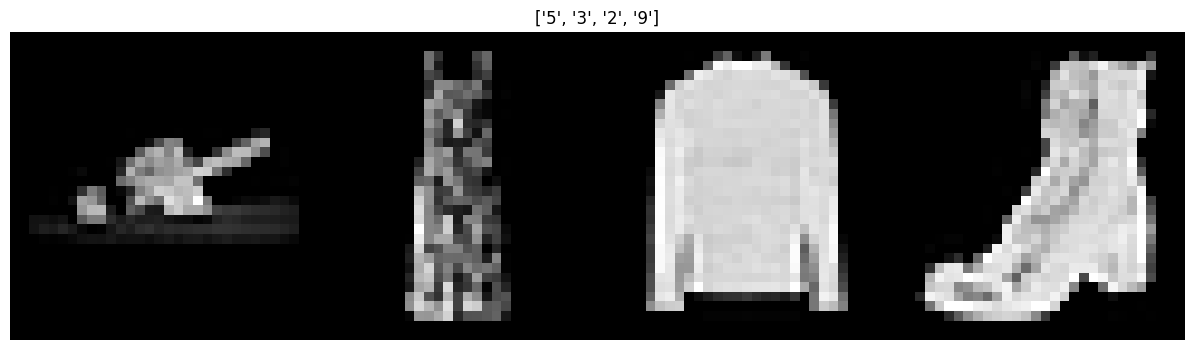

In [7]:
images, labels = show_batch_images(trainloader)

이제 모델의 네트워크를 구축해야 함. 배치 정규화가 적용된 모델과 비교를 위해 배치 정규화가 적용되지 않는 모델을 먼저 생성해보자.

In [8]:
class NormalNet(nn.Module):
  def __init__(self):
    super(NormalNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48), # (28,28) 크기의 이미지로 입력은 784(28x28) 크기가 됩니다.
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.ReLU(),
        nn.Linear(24, 10) # FashionMNIST의 클래스는 총 열 개
    ) # nn,Sequential을 사용하면 toward() 함수에서 계층(layer)별로 가독성 있게 코드 구현이 가능

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x) # nn.Sequential에서 정의한 계층 호출
    return x

이번에는 배치 정규화가 포함된 네트워크를 구축하자.

In [9]:
class BNNet(nn.Module):
  def __init__(self):
    super(BNNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48),
        nn.BatchNorm1d(48), # 1
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.BatchNorm1d(24),
        nn.ReLU(),
        nn.Linear(24, 10)
    )

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

배치 정규화가 적용되지 않은 모델을 선언(객체화)하자.

In [10]:
model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


배치 정규화가 적용된 모델을 선언(객체화)하자.

In [11]:
model_bn = BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


데이터로더를 이용하여 앞에서 내려받았던 데이터셋을 메모리로 불러올 준비를 함. 참고로 앞에서도 메모리로 불러오는 부분을 진행하자. 그때는 이미지 출력을 위한 용도로 배치 크기를 4로 설정했지만, 이번에 메모리로 불러오는 것은 학습을 위한 용도로 배치 크기를 512로 지정함.

In [12]:
batch_size = 512
trainloader = torch.utils.data.DataLoader(trainset, batch_size = batch_size, shuffle = True)

모델에서 사용할 옵티마이저와 손실 함수를 지정하자.

In [13]:
loss_fn = nn.CrossEntropyLoss()
opt = optim.SGD(model.parameters(), lr=0.01)
opt_bn = optim.SGD(model_bn.parameters(), lr=0.01)

이제 모델을 학습시켜 보자.

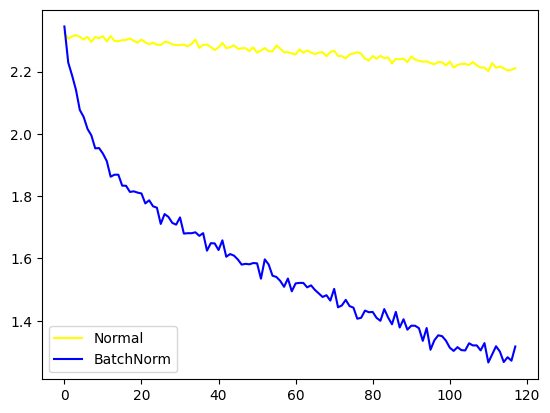

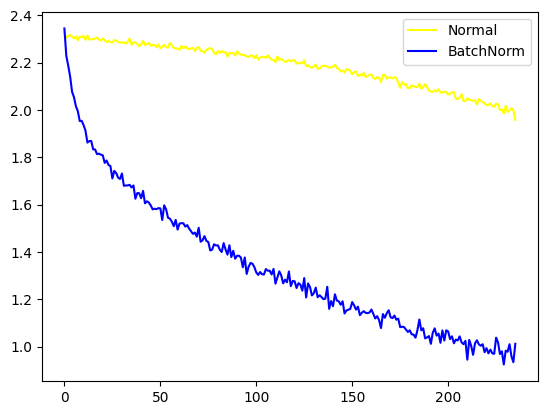

In [14]:
loss_arr = []
loss_bn_arr = []
max_epochs = 2

for epoch in range(max_epochs):
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data
    opt.zero_grad() # 배치 정규화가 적용되지 않은 모델의 학습
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    loss.backward()
    opt.step()

    opt_bn.zero_grad() # 배치 정규화가 적용된 모델의 학습
    outputs_bn = model_bn(inputs)
    loss_bn = loss_fn(outputs_bn, labels)
    loss_bn.backward()
    opt_bn.step()

    loss_arr.append(loss.item())
    loss_bn_arr.append(loss_bn.item())

  plt.plot(loss_arr, 'yellow', label='Normal')
  plt.plot(loss_bn_arr, 'blue', label='BatchNorm')
  plt.legend()
  plt.show()

드롭아웃을 알아보기에 앞서 훈련과 테스트 데이터셋이 어떻게 분포하는지 알아보자.

In [15]:
N = 50
noise = 0.3

x_train = torch.unsqueeze(torch.linspace(-1, 1, N), 1) # 1
y_train = x_train + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1)) # 2

x_test = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_test = x_test + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

앞에서 전처리된 데이터를 그래프로 출력하여 분포를 확인하자.

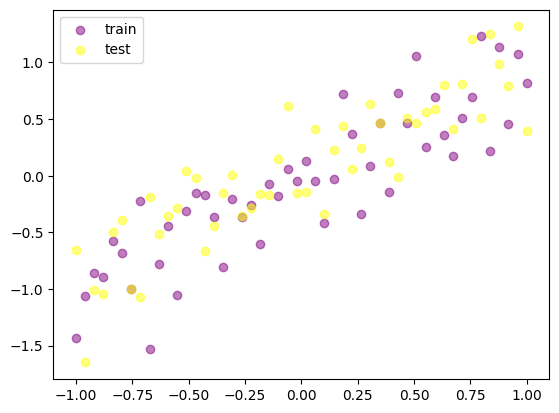

In [16]:
plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c = 'purple',
            alpha = 0.5, label = 'train') # 1
plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c = 'yellow',
            alpha = 0.5, label = 'test')
plt.legend()
plt.show()

드롭아웃의 효과를 확인하기 위해 드롭아웃이 적용된 것과 그렇지 않은 것의 모델을 생성하자.

In [17]:
N_h = 100
model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.ReLU(),
    torch.nn.Dropout(p = 0.5),
    torch.nn.Linear(N_h, 1),
) # 드롭아웃이 적용되지 않은 모델

model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(0.2), # 드롭아웃 적용
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
) # 드롭아웃이 적용된 모델

앞에서 생성한 모델을 위한 옵티마이저와 손실 함수를 지정하자.

In [18]:
opt = torch.optim.Adam(model.parameters(), lr = 0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr = 0.01)
loss_fn = torch.nn.MSELoss()

이제 드롭아웃이 적용된 모델과 그렇지 않은 모델을 학습시키고 오차를 그래프로 출력함.

/tmp/ipykernel_340/2616464378.py:33: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %


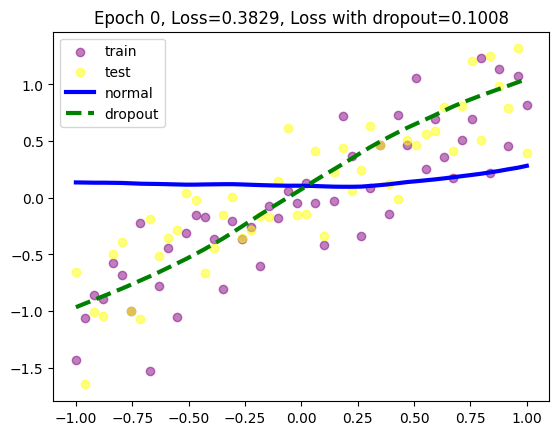

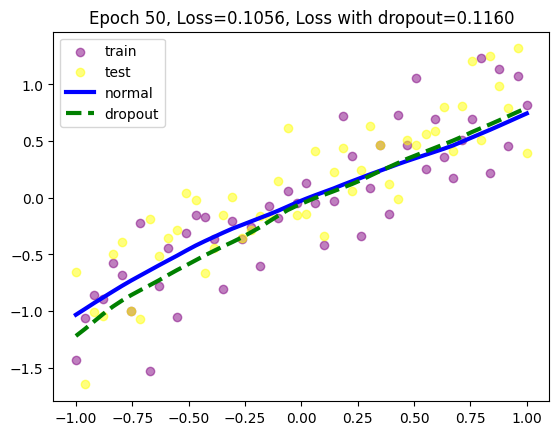

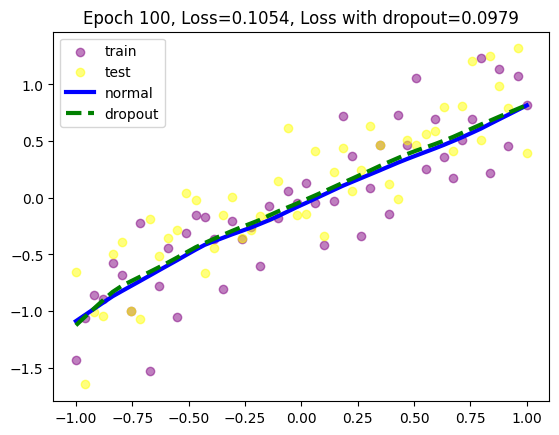

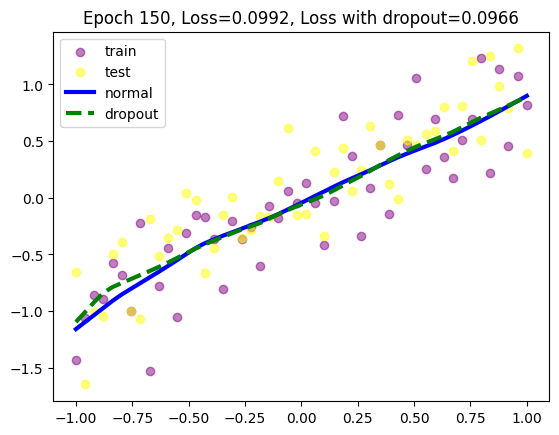

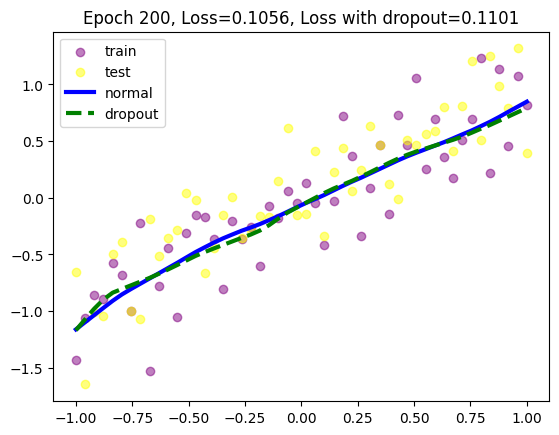

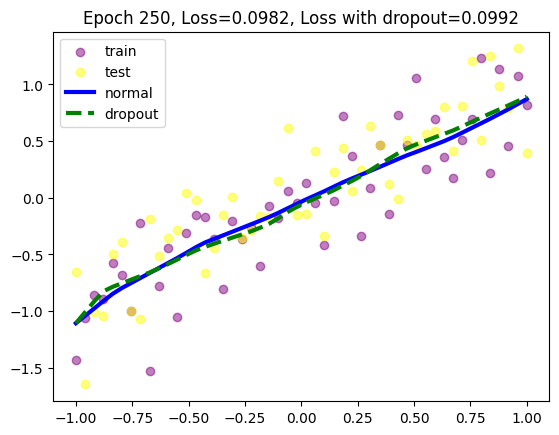

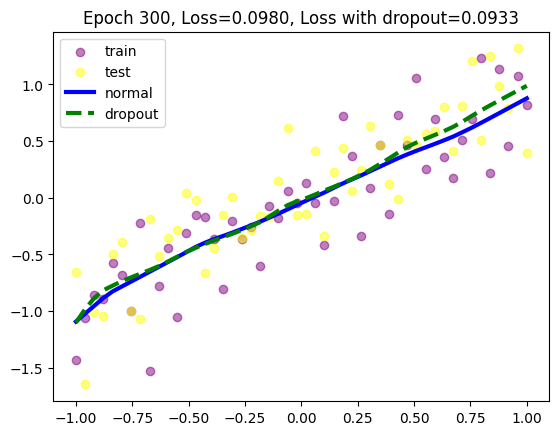

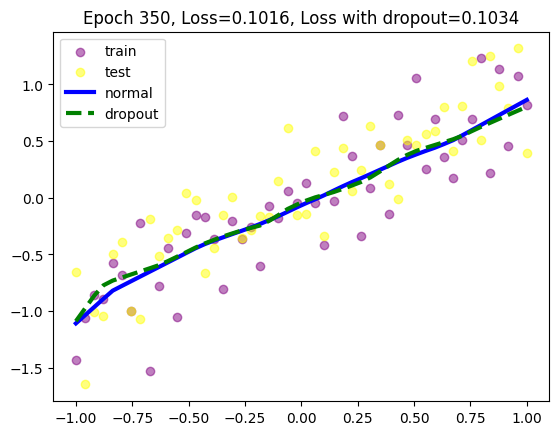

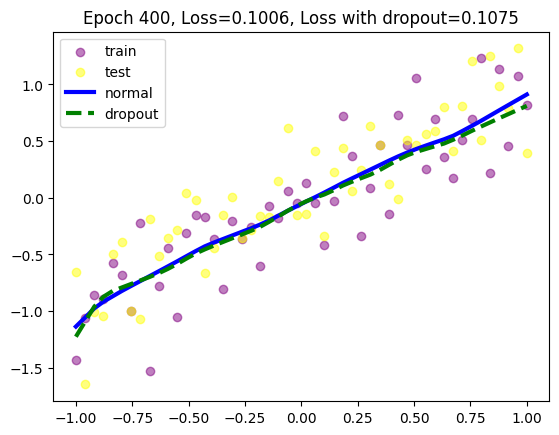

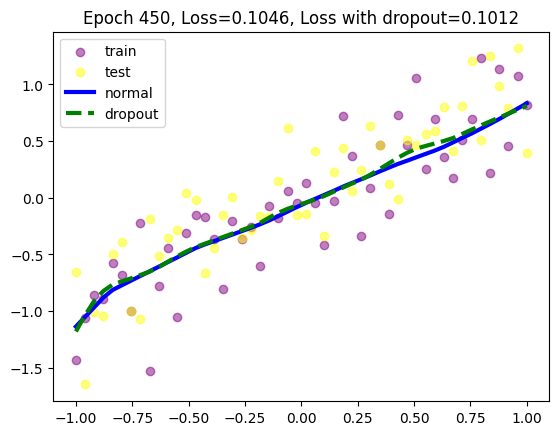

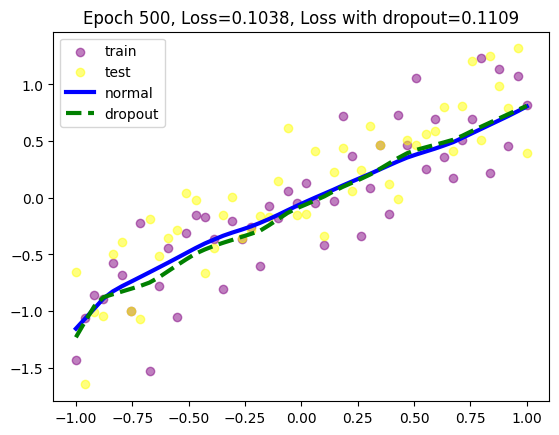

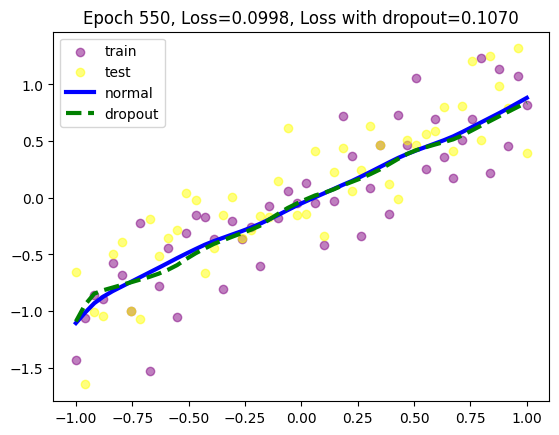

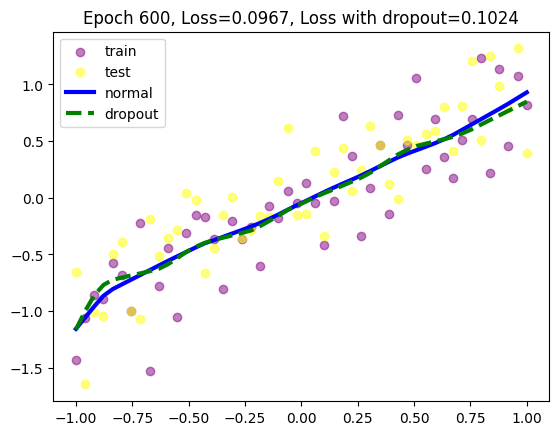

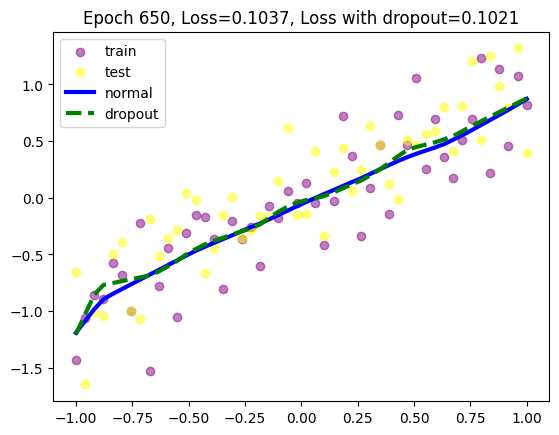

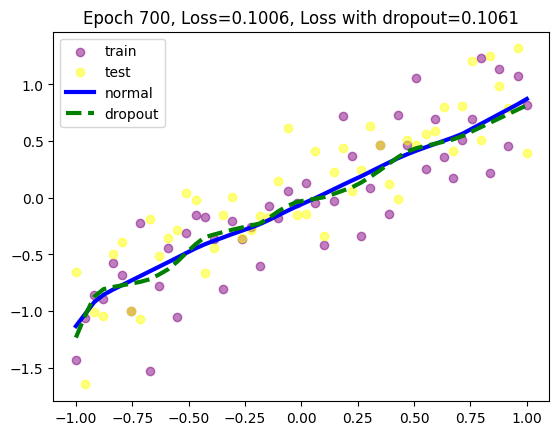

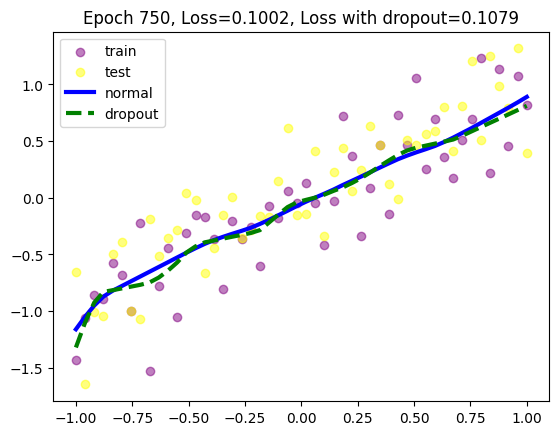

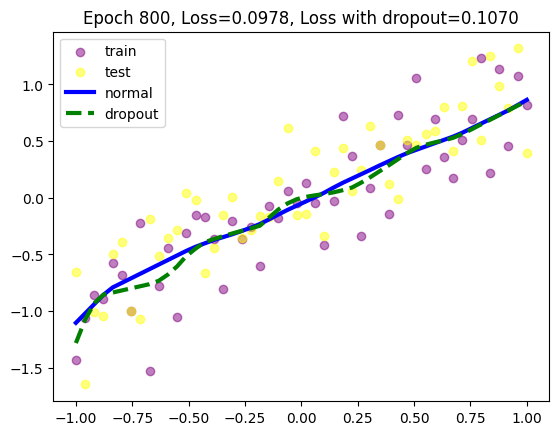

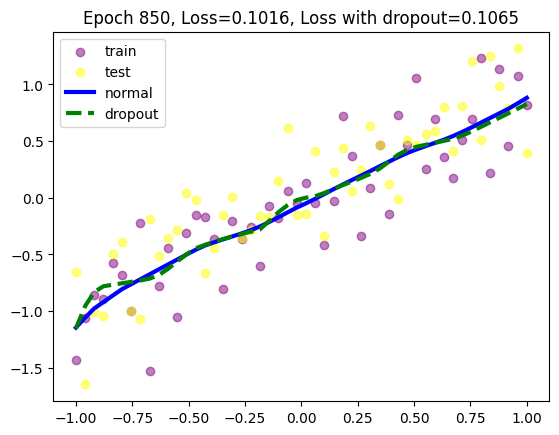

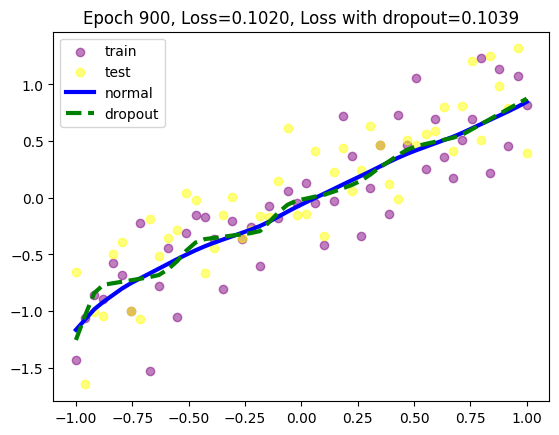

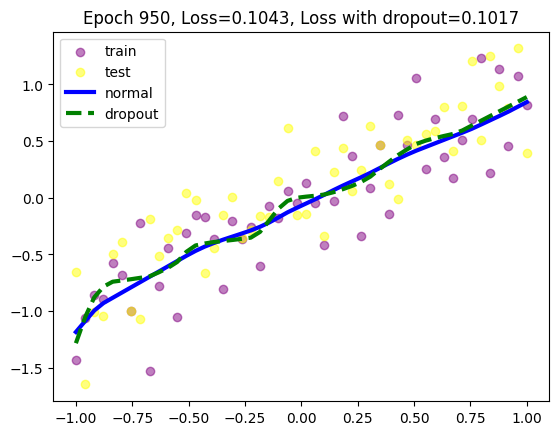

In [19]:
max_epochs = 1000
for epoch in range(max_epochs):
  pred = model(x_train) # 드롭아웃이 적용되지 않은 모델 학습
  loss = loss_fn(pred, y_train)
  opt.zero_grad()
  loss.backward()
  opt.step()

  pred_dropout = model_dropout(x_train) # 드롭아웃이 적용된 모델 학습
  loss_dropout = loss_fn(pred_dropout, y_train)
  opt_dropout.zero_grad()
  loss_dropout.backward()
  opt_dropout.step()

  if epoch % 50 == 0: # epoch를 50으로 나눈 나머지가 0이면 다음 진행
    model.eval()
    model_dropout.eval()

    test_pred = model(x_test)
    test_loss = loss_fn(test_pred, y_test)

    test_pred_dropout = model_dropout(x_test)
    test_loss_dropout = loss_fn(test_pred_dropout, y_test)

    plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple',
                alpha=0.5, label='train')
    plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
                alpha=0.5, label='test')
    plt.plot(x_test.data.numpy(), test_pred.data.numpy(), 'b-', lw=3,
             label='normal') # 파란색 실선으로 x축은 테스트 데이터셋, y축은 드롭아웃이 적용되지 않은 모델의 결과를 그래프로 출력
    plt.plot(x_test.data.numpy(), test_pred_dropout.data.numpy(), 'g--', lw=3,
             label='dropout') # 초록색 점선으로 x축은 테스트 데이터셋, y축은 드롭아웃이 적용된 모델의 결과를 그래프로 출력
    plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %
              (epoch, test_loss, test_loss_dropout)) # 에포크, 드롭아웃이 적용되지 않은 모델의 오차, 드롭아웃이 적용된 모델의 오차를 타이틀로 출력
    plt.legend()
    model.train()
    model_dropout.train()
    plt.pause(0.05)

## 8.3.3 조기 종료를 이용한 성능 최적화
- 조기 종료 : 뉴럴 네트워크가 과적합을 회피하는 규제 기법임. 훈련 데이터와 별도로 검증 데이터를 준비하고, 매 에포크마다 검증 데이터에 대한 오차를 측정하여 모델의 종료 시점을 제어함.

이번 예제는 조기 종료뿐만 아니라 학습률을 조정해서 성능을 향상시키는 방법에 대해서도 함께 알아보자. 먼저 필요한 라이브러리들을 호출하자.

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models # 사전 학습된 모델을 이용하고자 할 때 사용하는 라이브러리
from torchvision import transforms, datasets

import matplotlib
import matplotlib.pyplot as plt
import time
import argparse
from tqdm import tqdm
matplotlib.style.use('ggplot') # 출력 그래프에서 격자로 숫자 범위가 눈에 잘 띄도록 하는 스타일
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

다음은 데이터셋 전처리를 위한 항목들을 정의하자. 전처리에는 데이터 크기 조정 및 데이터 정규화(분포 조정) 등이 포함됨.

In [21]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

예제를 진행할 데이터셋을 배치 크기로 메모리로 가져오기 위한 준비를 하자.

In [22]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2278 (delta 3), reused 2 (delta 2), pack-reused 2262 (from 2)
Receiving objects: 100% (2278/2278), 330.29 MiB | 27.31 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [23]:
train_dataset = datasets.ImageFolder(
    root=r'080289/chap08/data/archive/train',
    transform = train_transform
)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size = 32, shuffle = True,
)
val_dataset = datasets.ImageFolder(
    root =r'080289/chap08/data/archive/test',
    transform = val_transform
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size = 32, shuffle = False,
)

이제 모델을 생성할 텐데, 네트워크를 직접 구축하는 것이 아닌 사전 학습된 ResNet50을 사용할 예정임.

In [24]:
def resnet50(pretrained=True, requires_grad=False):
  model = models.resnet50(progress=True, pretrained=pretrained)
  if requires_grad == False: # 파라미터를 고정하여 backward() 중에 기울기가 계산되지 않도록 합니다. requires_grad=False를 파라미터로 받았기 때문에 해당 구문이 실행됩니다.
    for param in model.parameters():
      param.requires_grad = False
  elif requires_grad == True: # 파라미터 값이 backward() 중에 기울기 게산에 반영됩니다.
    for param in model.parameters():
      param.requires_grad = True
  model.fc = nn.LInear(2048, 2) # 마지막 분류를 위한 계층은 학습을 진행합니다.
  return model

In [25]:
class LRScheduler():
  def __init__(
      self, optimizer, patience = 5, min_lr = 1e-6, factor = 0.5
  ):
      self.optimizer = optimizer
      self.patience = patience
      self.min_lr = min_lr
      self.factor = factor
      self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
          self.optimizer,
          mode = 'min',
          patience = self.patience,
          factor = self.factor,
          min_lr = self.min_lr,
          verbose = True
      ) # 1

  def __call__(self, val_loss):
    self.lr_scheduler.step(val_loss) # 2

이번에는 조기 종료에 대한 클래스임. 특정 에포크 후에도 오차가 개선되지 않을 때 훈련을 조기 종료함.

In [26]:
class EarlyStopping():
  def __init__(self, patience = 5, verbose=False, delta=0,
               path = '080289/chap08/data/checkpoint.pt'):
    self.patience = patience # 1
    self.verbose = verbose
    self.coutner = 0
    self.best_score = None # 검증 데이터셋에 대한 오차 최적화 값(오차가 가장 낮은 값)
    self.early_stop = False # 조기 종료를 의미하며 초깃값은 False로 설정
    self.val_loss_min = np.Inf # np.Inf(infinity)는 넘파이에서 무한대를 표현
    self.delta = delta # 2
    self.path = path # 모델이 저장될 경로

  def __call__(self, val_loss, model): # 에포크만큼 학습이 반복되면서 best_loss가 갱신되고, best_loss에 진전이 없으면 조기 종료한 후 모델을 저장
    score = -val_loss
    if self.best_score is None: # best_score에 값이 존재하지 않으면 실행
      self.best_score = score
      self.save_checkpoint(val_loss, model)
    elif score < self.best_score + self.delta: # best_score + delta가 score보다 크면 실행
      self.counter += 1
      print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
      if self.counter >= self.patience:
        self.early_stop = True
    else: # 그 외 모든 경우에 실행
      self.best_score = score
      self.save_checkpoint(val_loss, model)
      self.counter = 0

  def save_checkpoint(self, val_loss, model): # 검증 데이터셋에 대한 오차가 감소하면 모델을 저장
    if self.verbose:
      print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
    torch.save(model.state_dict(), self.path) # 지정된 경로에 모델 저장
    self.val_loss_min = val_loss

ArgumentParser()를 이용하여 변수와 타입을 정의해 주고 add_argument()를 이용해서 변수에 인수 값을 하나씩 추가하자. 그리고 마지막으로 parse_args()를 통해 사용자로부터 입력받은 값들을 args 변수에 저장함.

In [27]:
parser = argparse.ArgumentParser()
parser.add_argument('--lr-scheduler', dest = 'lr_scheduler', action = 'store_true') # 1
parser.add_argument('--early-stopping', dest = 'early_stopping', action = 'store_true') # 조기 종료에 대한 인수
args, unknown = parser.parse_known_args() # 2
args = vars(args)

In [28]:
print(f"Computation device: {device}\n") # CPU를 사용하는지 GPU를 사용하는지 검사
model = models.resnet50(pretrained=True).to(device) # 사전 훈련된 ResNet50 사용
total_params = sum(p.numel() for p in model.parameters()) # 총 파라미터 수
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad) # 학습 가능한 파라미터 수
print(f"{total_trainable_params:,} training parameters.")

Computation device: cuda:0



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 168MB/s]


25,557,032 total parameters.
25,557,032 training parameters.


초기 학습률, 에포크 및 옵티마이저와 손실 함수를 지정하자.

In [29]:
lr = 0.001
epochs = 100
optimizer = optim.Adam(model.parameters(), lr = lr)
criterion = nn.CrossEntropyLoss()

'--lr-scheduler' 또는 '--early-stopping'처럼 어떤 인수도 사용하지 않을 때 오차, 정확도 및 모델의 이름으로 사용할 문자열을 지정함.

In [30]:
loss_plot_name = 'loss' # 오차 출력에 대한 문자열
acc_plot_name = 'accuracy' # 정확도 출력에 대한 문자열
model_name = 'model' # 모델을 저장하기 위한 문자열

'--lr-scheduler' 또는 '--early-stopping' 인수를 사용할 경우 오차, 정확도 및 모델의 이름으로 사용할 문자열을 지정함.

In [31]:
if args['lr_scheduler']:
  print('INFO: Initializing learning rate scheduler')
  lr_scheduler = LRScheduler(optimizer)
  loss_plot_name = 'lrs_loss' # 학습률 감소를 적용했을 때의 오차에 대한 문자열
  acc_plt_name = 'lrs_accuracy' # 학습률 감소를 적용했을 때의 정확도에 대한 문자열
  model_name = 'lrs_model' # 학습률 감소를 적용했을 때의 모델에 대한 문자열
if args['early_stopping']:
  print('INFO: Initializing early stopping')
  early_stopping = EarlyStopping()
  loss_plot_name = 'es_loss' # 조기 종료를 적용했을 때의 오차에 대한 문자열
  acc_plot_name = 'es_accuracy' # 조기 종료를 적용했을 때의 정확도에 대한 문자열
  model_name = 'es_model' # 조기 종료를 적용했을 때의 모델에 대한 문자열

훈련 데이터셋을 이용한 모델 학습 함수를 정의하자.

In [32]:
def training(model, train_dataloader, train_dataset, optimizer, criterion):
  print('Training')
  model.train()
  train_running_loss = 0.0
  train_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(train_dataloader), total = int(len(train_dataset)/
                                                           train_dataloader.batch_size)) # 훈련 진행 과정을 시각적으로 표현
  for i, data in prog_bar:
    counter += 1
    data, target = data[0].to(device), data[1].to(device)
    total += target.size(0)
    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, target)
    train_running_loss += loss.item()
    _, preds = torch.max(outputs.data, 1)
    train_running_correct += (preds == target).sum().item()
    loss.backward()
    optimizer.step()

  train_loss = train_running_loss / counter
  train_accuracy = 100. * train_running_correct / total
  return train_loss, train_accuracy

다음은 모델 성능을 검증하기 위한 함수임.

In [33]:
def validate(model, test_dataloader, val_dataset, criterion):
  print('Validating')
  model.eval()
  val_running_loss = 0.0
  val_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(test_dataloader), total=int(len(val_dataset)/
                                                        test_dataloader.batch_size)) # 모델 검증 과정을 시각적으로 표현
  with torch.no_grad():
    for i, data in prog_bar:
      counter += 1
      data, target = data[0].to(device), data[1].to(device)
      total += target.size(0)
      outputs = model(data)
      loss = criterion(outputs, target)

      val_running_loss += loss.item()
      _, preds = torch.max(outputs.data, 1)
      val_running_correct += (preds == target).sum().item()

    val_loss = val_running_loss / counter
    val_accuracy = 100. * val_running_correct / total
    return val_loss, val_accuracy

데이터셋과 모델에 대한 준비가 완료됨. 이제 모델을 학습시켜보자.

In [34]:
train_loss, train_accuracy = [], [] # 훈련 데이터셋을 이용한 모델 학습 결과(오차, 정확도)를 저장하기 위한 변수(리스트 형태를 갖습니다)
val_loss, val_accuracy = [], [] # 검증 데이터셋을 이용한 모델 성능 결과(오차, 정확도)를 저장하기 위한 변수(리스트 형태를 갖습니다)

start = time.time()
for epoch in range(epochs):
  print(f"Epoch {epoch+1} of {epochs}")
  train_epoch_loss, train_epoch_accuracy = training(
      model, train_dataloader, train_dataset, optimizer, criterion
  )
  val_epoch_loss, val_epoch_accuracy = validate(
      model, val_dataloader, val_dataset, criterion
  )
  train_loss.append(train_epoch_loss)
  train_accuracy.append(train_epoch_accuracy)
  val_loss.append(val_epoch_loss)
  val_accuracy.append(val_epoch_accuracy)
  if args['lr_scheduler']: # 인수 값이 lr_scheduler이면 다음을 실행
    lr_scheduler(val_epoch_loss)
  if args['early_stopping']: # 인수 값이 early_stopping이면 다음을 실행
    early_stopping(val_epoch_loss, model)
    if early_stopping.early_stop:
      break
  print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
  print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}")
  end = time.time()
  print(f"Training time: {(end-start)/60:.3f} minutes")

Epoch 1 of 100
Training


16it [00:06,  2.52it/s]


Validating


16it [00:03,  4.74it/s]


Train Loss: 2.0588, Train Acc: 59.24
Val Loss: 17.5520, Val Acc: 54.00
Training time: 0.162 minutes
Epoch 2 of 100
Training


...

Train Loss: 0.0808, Train Acc: 97.59
Val Loss: 0.9857, Val Acc: 76.00
Training time: 15.575 minutes
Epoch 100 of 100
Training


16it [00:05,  2.82it/s]


Validating


16it [00:03,  4.39it/s]

Train Loss: 0.1078, Train Acc: 96.39
Val Loss: 1.6258, Val Acc: 73.60
Training time: 15.731 minutes


모델의 정확도와 오차를 그래프를 통해서 확인해 보자. 이때 출력 결과는 어떤 인수도 사용되지 않는 모델의 학습 결과임.

Saving loss and accuracy plots...


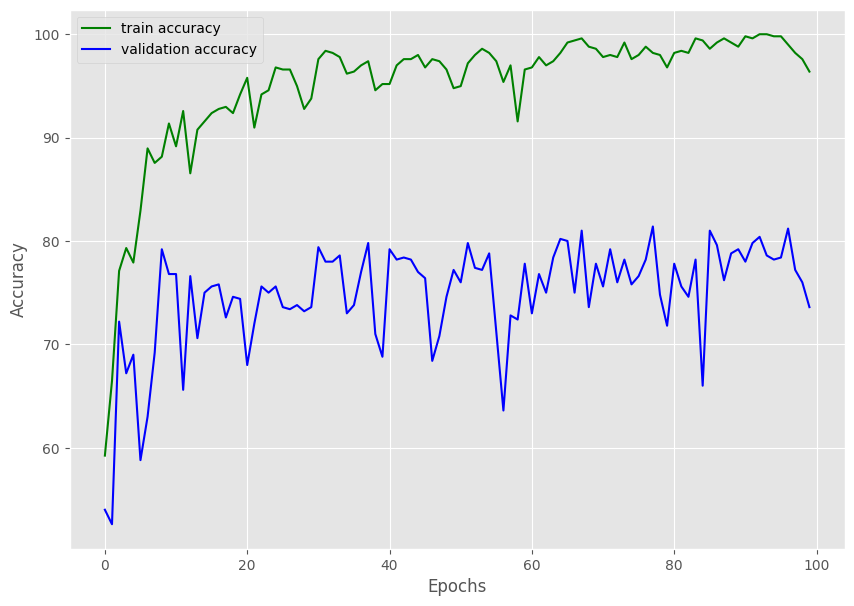

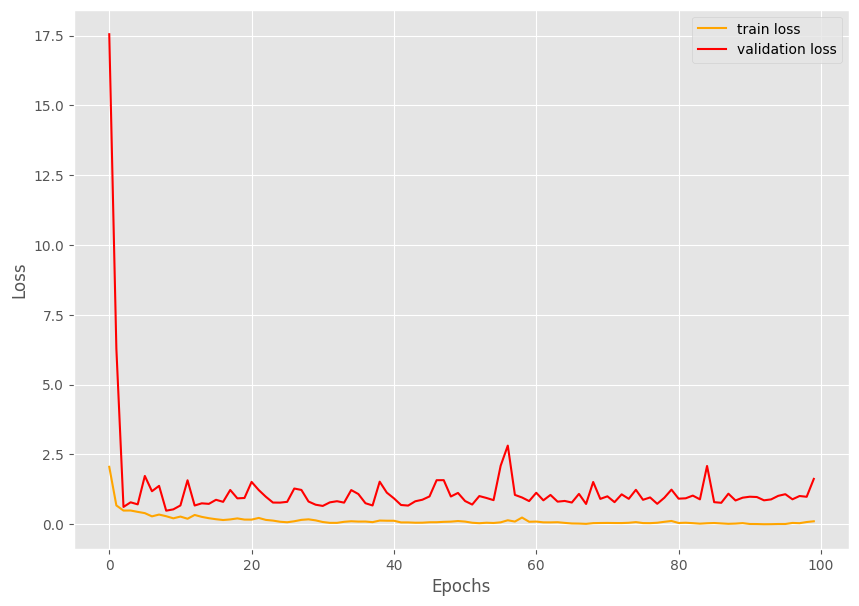

Saving model...
TRAINING COMPLETE


In [35]:
print('Saving loss and accuracy plots...')
plt.figure(figsize = (10, 7))
plt.plot(train_accuracy, color = 'green', label = 'train accuracy') # 훈련 데이터셋에 대한 정확도를 그래프로 출력
plt.plot(val_accuracy, color = 'blue', label = 'validation accuracy') # 검증 데이터셋에 대한 정확도를 그래프로 출력
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'080289/chap08/data/{acc_plot_name}.png')
plt.show()
plt.figure(figsize = (10, 7))
plt.plot(train_loss, color = 'orange', label = 'train loss') # 훈련 데이터셋에 대한 오차를 그래프로 출력
plt.plot(val_loss, color = 'red', label = 'validation loss') # 검증 데이터셋에 대한 오차를 그래프로 출력
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'080289/chap08/data/{loss_plot_name}.png')
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f'080289/chap08/data/{model_name}.pt') # 모델을 저장
print('TRAINING COMPLETE')